# Decoding Analysis

Applies PCA to activity data to obtain decoding manifolds (averaged over time) and decoding trajectories (dynamics over time).

In [1]:
import pickle
import logging

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import savemat
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import lsq_linear
from scipy.sparse import load_npz
from scipy.spatial.distance import squareform, pdist, cdist
import tueplots
from tueplots import bundles
from tueplots.constants.color import rgb
from sklearn.decomposition import PCA
import plotly.graph_objects as go

import sys, os; _d = os.path.abspath(os.getcwd()); sys.path.insert(0, _d if os.path.isdir(os.path.join(_d, 'src')) else os.path.dirname(_d))
from src import *

logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

plt.rcParams.update(bundles.neurips2021(usetex=False))

results_dict = {}


In [2]:
PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_inputs0_maxFr_maxNr_seed1"; low_sf = True
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_blocks0_maxFr_maxNr_seed1"; low_sf = False
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_inputs1_maxFr_maxNr_seed1"; low_sf = False
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_blocks1_maxFr_maxNr_seed1"; low_sf = False
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_inputs2_maxFr_maxNr_seed1"; low_sf = True
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_blocks2_maxFr_maxNr_seed1"; low_sf = True
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_hidden_maxFr_maxNr_seed1"; low_sf = False
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_recurrentout_maxFr_maxNr_seed1"; low_sf = False
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_position_maxFr_maxNr_seed1"; low_sf = False
#PREFIX = "fnn07_seed2"; low_sf = False

#PREFIX = "flyvis_Retina_i3_n400_model000"; low_sf = True
#PREFIX = "flyvis_Lamina_i3_n350_model000"; low_sf = True
#PREFIX = "flyvis_Medulla_i3_n550_model000"; low_sf = True
#PREFIX = "flyvis_T_Tm_i3_n1700_model000"; low_sf = True

#PREFIX = "VISp_natural_movie_one_scenes20"; low_sf = None
PREFIX = "VISp_natural_movie_one_scenes_all156"; low_sf = None

#PREFIX = "Retina"; low_sf = True
#PREFIX = "V1"; low_sf = True

#PREFIX = "res50_shifted_act_i3_n1000_SCL0_5_TL37_layer1_maxFr_maxNr_seed1"; low_sf = False
#PREFIX = "res50_shifted_act_i3_n1000_SCL0_5_TL37_layer4_maxFr_maxNr_seed1"; low_sf = False

# Stimulus-index slices for the 11-stim tensor:
#   low_sf=True  → first 6 stims: 3 gratings + 3 low-SF dot flows
#   low_sf=False → remaining 6: indices 0 (LF-grat) + 6–10 (high-SF variants)
LOW_SF_INDICES  = slice(0, 6)            # stimuli 0–5: low spatial frequency set
HIGH_SF_INDICES = np.array([0, 6, 7, 8, 9, 10])  # LF-grat plus high-SF stimuli

# Ensure output figure directories exist
os.makedirs('../fig/decoding_manifolds', exist_ok=True)
os.makedirs('../fig/decoding_trajectories', exist_ok=True)


## Load activity data

In [3]:
basedir = '../data/sampled'

if PREFIX == "V1":
    tensor4d = np.load("../data/biological/V1_tensor_traces.npy")
elif PREFIX == "Retina":
    tensor4d = np.load("../data/biological/retina_tensor_traces.npy")
else:
    tensor4d = np.load(f'{basedir}/tensor4d_{PREFIX}.npy')

n_neurons, n_stim, n_ori, trial_len = tensor4d.shape

if low_sf is None or n_stim != 11:
    pass  # use all stimuli as-is
elif low_sf:
    tensor4d = tensor4d[:, LOW_SF_INDICES]
    n_neurons, n_stim, n_ori, trial_len = tensor4d.shape
else:
    tensor4d = tensor4d[:, HIGH_SF_INDICES]
    n_neurons, n_stim, n_ori, trial_len = tensor4d.shape

print(f"(Neurons, Stimuli, Orientation, Trial len): {tensor4d.shape}")


(Neurons, Stimuli, Orientation, Trial len): (2015, 14, 1, 156)


In [4]:
# For trajectories
transposed = np.transpose(tensor4d, (3, 1, 2, 0))  # (T, S, D, N)

# Identify padded frames (all neurons NaN at that position) for NaN-padded tensors
_padded_mask = np.all(np.isnan(transposed), axis=-1)  # (T, S, D)
_flat = transposed.reshape(-1, len(tensor4d))         # (T*S*D, N)
_valid_rows = ~_padded_mask.reshape(-1)               # (T*S*D,)

# Fit PCA only on valid frames — padded rows never enter the PCA
_valid_data = _flat[_valid_rows]
_valid_data = np.where(np.isfinite(_valid_data), _valid_data, 0.0)
print(_valid_data.shape)

# sklearn PCA may emit numerical warnings (divide by zero / overflow / invalid)
# on near-zero rows that occur in some layers — these are expected and can be ignored.
pca_traj = PCA(n_components=3)
_valid_pca = pca_traj.fit_transform(_valid_data)
pc1_loadings = pca_traj.components_[0]

# Reconstruct full trajectory array; padded positions stay NaN
_full_pca = np.full((tensor4d.shape[3] * n_stim * n_ori, 3), np.nan)
_full_pca[_valid_rows] = _valid_pca
reshaped_traj_result = _full_pca.reshape(tensor4d.shape[3], n_stim * n_ori, 3)
trajectories = np.transpose(reshaped_traj_result, (1, 0, 2))  # (S*D, T, 3)


# For Decoding Manifold: Meaned traces (nanmean ignores NaN-padded frames)
first_n_points = tensor4d.shape[3]

meaned = np.nanmean(transposed[:first_n_points], axis=0)
reshaped = meaned.reshape(-1, len(tensor4d))

pca_decoding = PCA(n_components=3)
pca_decoding_result = pca_decoding.fit_transform(reshaped)
print(np.sum(pca_decoding.explained_variance_ratio_))

reshaped_decoding_result = pca_decoding_result.reshape(n_stim*n_ori, -1)

(900, 2015)
0.6674794


## Decoding Manifold

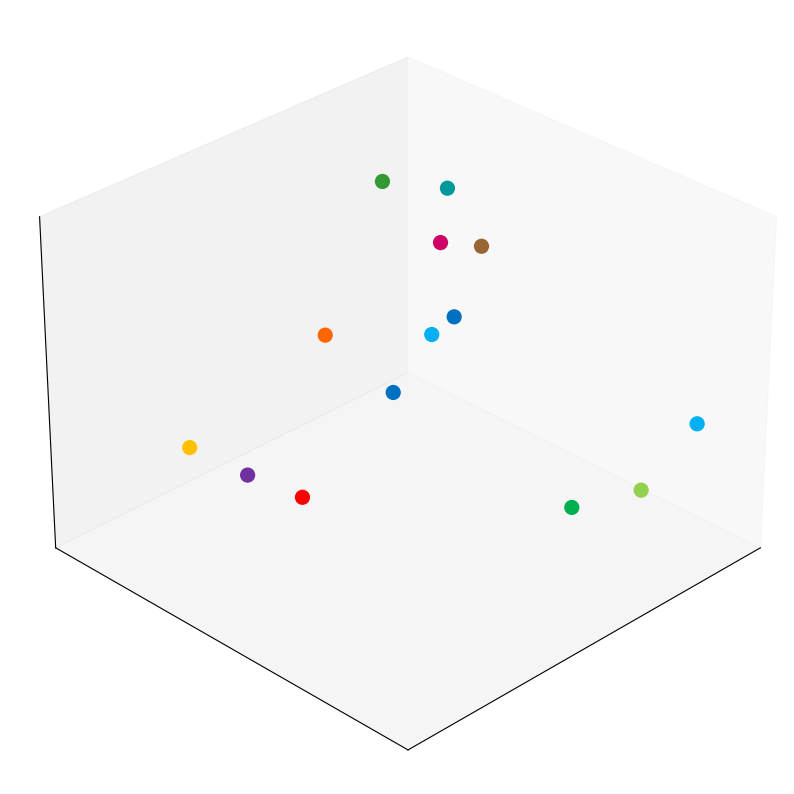

In [5]:
import math as _math

_KNOWN_STIM_LABELS = {
    6:  ['LF-grat', 'HF-grat', '-1dot', '-3dot', '+1dot', '+3dot'],
    11: ['LF-grat', 'HF-grat', '-1dot', '-3dot', '+1dot', '+3dot',
         'HF-grat-2', '-1dot-2', '-3dot-2', '+1dot-2', '+3dot-2'],
}
_PALETTE = ['#0070C0', '#00B0F0', '#00B050', '#92D050', '#FF0000', '#FFC000',
            '#7030A0', '#FF6600', '#339933', '#CC0066', '#009999', '#996633']

labels = _KNOWN_STIM_LABELS.get(n_stim, [f'stim {i}' for i in range(n_stim)])
stimulus_colors = (_PALETTE * _math.ceil(n_stim / len(_PALETTE)))[:n_stim]

n_per_label = n_ori
clrs = []
legend_labels = []
for i in range(n_stim):
    clrs.extend([stimulus_colors[i]] * n_per_label)
    legend_labels.extend([labels[i]] * n_per_label)
clrs = np.array(clrs)
legend_labels = np.array(legend_labels)

# Create Matplotlib Figure
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot each group
for i, label in enumerate(labels):
    mask = (legend_labels == label)
    if np.any(mask):
        ax.scatter(
            reshaped_decoding_result[mask, 0],
            reshaped_decoding_result[mask, 1],
            reshaped_decoding_result[mask, 2],
            color=stimulus_colors[i],
            s=120,
            label=label,
            alpha=1.0,
            edgecolors='none'
        )

ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.view_init(elev=30, azim=45)

plt.savefig(f'../fig/decoding_manifolds/{PREFIX}_decoding.pdf', format='pdf', bbox_inches='tight', dpi=300)

## Plot Trajectories and Crossings

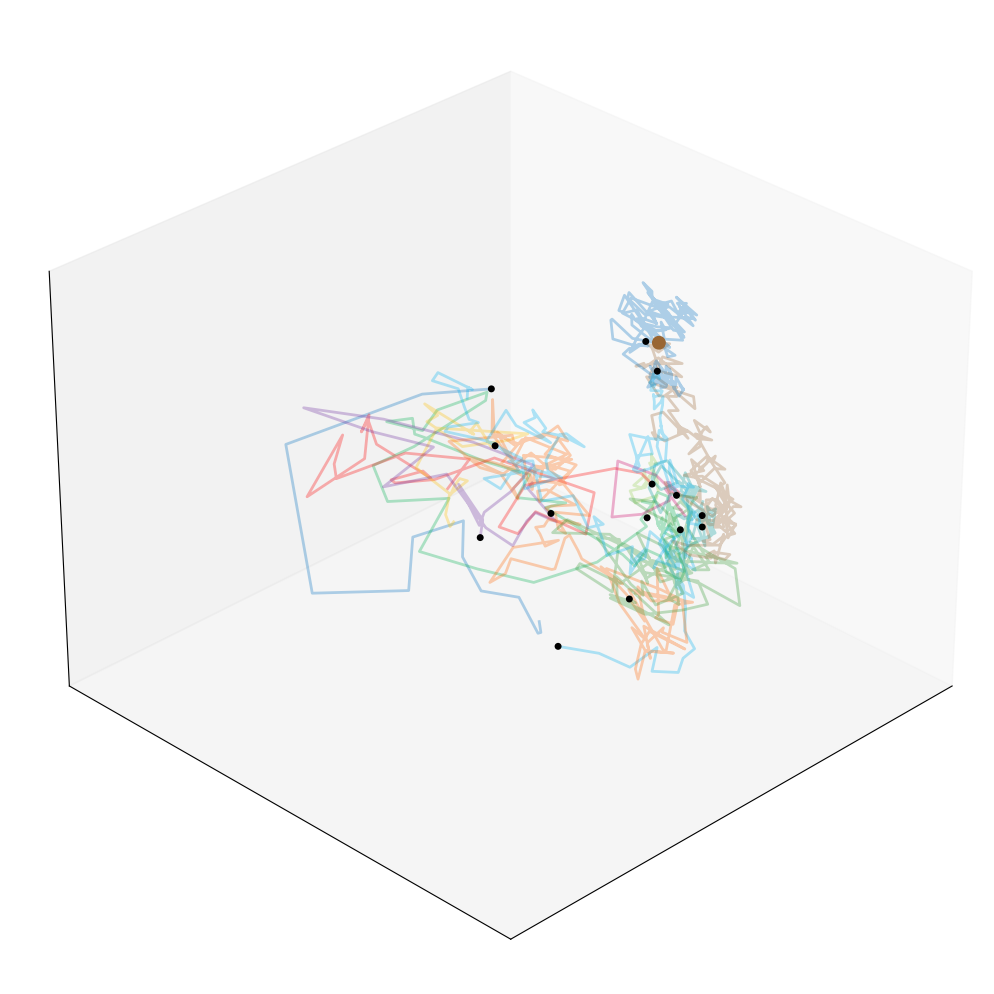

Saved to ../fig/decoding_trajectories/crossings_VISp_natural_movie_one_scenes_all156.pdf


In [6]:
def plot_trajectories_matplotlib(trajectories, prefix="prefix", filename="filename",
                                 stimulus_colors=None, n_ori=8):
    """
    Plot 3D trajectories using Matplotlib (Vector/PDF safe).
    """
    # 1. Setup Colors and Names
    if stimulus_colors is None:
        stimulus_colors = [
            '#0070C0', '#00B0F0', '#00B050', '#92D050', '#FF0000', '#FFC000',
            '#00B0F0', '#00B050', '#92D050', '#FF0000', '#FFC000'
        ]

    # 2. Initialize Figure
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # 3. Plot Loop
    for i, traj in enumerate(trajectories):
        x, y, z = traj[:, 0], traj[:, 1], traj[:, 2] * 0.5  # z * 0.5: cosmetic scale to reduce depth distortion

        # Determine grouping
        stimulus_idx = i // n_ori
        stimulus_color = stimulus_colors[stimulus_idx % len(stimulus_colors)]

        # A. Plot the Trajectory Line
        ax.plot(
            x, y, z,
            color=stimulus_color,
            linewidth=2,
            alpha=0.3
        )

        # B. Start Point (Black)
        ax.scatter(
            x[0], y[0], z[0],
            color='black',
            s=25,
            depthshade=False,
            edgecolors='none'
        )

        # C. End Point (Stimulus Colored)
        ax.scatter(
            x[-1], y[-1], z[-1],
            color=stimulus_color,
            s=100,
            depthshade=False,
            edgecolors='none'
        )

    # 4. Styling
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.xaxis.line.set_color('black')
    ax.yaxis.line.set_color('black')
    ax.zaxis.line.set_color('black')
    ax.view_init(elev=30, azim=45)

    # 5. Save
    output_path = f'../fig/decoding_trajectories/crossings_{prefix}.pdf'
    plt.savefig(output_path, format='pdf', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close(fig)
    print(f"Saved to {output_path}")

# Usage:
plot_trajectories_matplotlib(trajectories, prefix=PREFIX,
                             stimulus_colors=stimulus_colors, n_ori=n_ori)


## Silhouette Score — Decoding Manifold Separability

Quantifies stimulus-cluster separability in the decoding manifold (PCA-3D) at each layer via silhouette score.
Bootstrap over neurons (1000 reps) gives 95% CI.
One-sided Mann-Whitney U test (V1 > FNN layer) gives p-values for whether each FNN layer is significantly lower than V1.

In [ ]:
from sklearn.metrics import silhouette_score
from src.subpop_utils import compute_decoding_manifold

DATASETS = [
    dict(path='../data/sampled/tensor4d_retina.npy',
         label='Retina',  group='bio',  stim_filter=None),
    dict(path='../data/sampled/tensor4d_V1.npy',
         label='V1',      group='bio',  stim_filter=None),
    dict(path='../data/sampled/tensor4d_fnn07_act_i3_n2000_SCL0_7_TL37_inputs0_maxFr_maxNr_seed1.npy',
         label='Enc1',    group='fnn',  stim_filter='fnn'),
    dict(path='../data/sampled/tensor4d_fnn07_act_i3_n2000_SCL0_7_TL37_blocks2_maxFr_maxNr_seed1.npy',
         label='Enc13',   group='fnn',  stim_filter='fnn'),
    dict(path='../data/sampled/tensor4d_fnn07_act_i3_n2000_SCL0_7_TL37_hidden_maxFr_maxNr_seed1.npy',
         label='Rec',     group='fnn',  stim_filter='fnn'),
    dict(path='../data/sampled/tensor4d_fnn07_act_i3_n2000_SCL0_7_TL37_position_maxFr_maxNr_seed1.npy',
         label='RecOut',  group='fnn',  stim_filter='position'),
    dict(path='../data/sampled/tensor4d_fnn07_seed2.npy',
         label='Output',  group='fnn',  stim_filter='fnn'),
]

N_BOOTSTRAP  = 1000   # neuron resample reps for 95% CI
N_COMPONENTS = 3      # PCA dims for decoding manifold
RNG_SEED     = 42

In [ ]:
from scipy.stats import mannwhitneyu

def apply_stim_filter(data, stim_filter):
    """Same stimulus selection as notebook 05."""
    if stim_filter == 'position':
        return data[:, :6]
    elif stim_filter == 'fnn':
        return data[:, np.array([0, 6, 7, 8, 9, 10])]
    return data


results = {}
rng = np.random.default_rng(RNG_SEED)

for ds in DATASETS:
    lbl = ds['label']
    print(f'\n=== {lbl} ===')
    data = np.load(ds['path'])                       # (N, S, D, T)
    data = apply_stim_filter(data, ds['stim_filter'])
    N, NSTIMS, NDIRS, _ = data.shape
    stim_labels = np.repeat(np.arange(NSTIMS), NDIRS)  # (S*D,)

    # 1. Observed silhouette
    coords, _ = compute_decoding_manifold(data, n_components=N_COMPONENTS)
    sil_obs = float(silhouette_score(coords, stim_labels))
    print(f'  Observed silhouette: {sil_obs:.4f}')

    # 2. Bootstrap CI — resample neurons
    boot_sils = []
    for _ in range(N_BOOTSTRAP):
        idx = rng.integers(0, N, size=N)
        bc, _ = compute_decoding_manifold(data[idx], n_components=N_COMPONENTS)
        boot_sils.append(float(silhouette_score(bc, stim_labels)))
    boot_sils = np.array(boot_sils)
    ci_lo, ci_hi = float(np.percentile(boot_sils, 2.5)), float(np.percentile(boot_sils, 97.5))
    print(f'  95% CI: [{ci_lo:.4f}, {ci_hi:.4f}]')

    results[lbl] = dict(
        sil=sil_obs, ci_lo=ci_lo, ci_hi=ci_hi,
        boot_sils=boot_sils, group=ds['group']
    )

# One-sided Mann-Whitney U test: H1 = V1 > FNN layer
v1_boots = results['V1']['boot_sils']
for lbl, r in results.items():
    if r['group'] == 'fnn':
        stat, p = mannwhitneyu(v1_boots, r['boot_sils'], alternative='greater')
        r['p_vs_v1'] = float(p)
        print(f"  {lbl} vs V1: p = {p:.4e}")
    else:
        r['p_vs_v1'] = None

# Results table
print(f"\n{'Layer':<10} {'Silhouette':>12} {'CI lo':>8} {'CI hi':>8} {'p vs V1':>12} {'sig':>5}")
print('-' * 65)
for lbl in [ds['label'] for ds in DATASETS]:
    r = results[lbl]
    p = r['p_vs_v1']
    if p is None:
        p_str, stars = '   —', '  —'
    else:
        p_str = f'{p:.4e}'
        stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"{lbl:<10} {r['sil']:>12.4f} {r['ci_lo']:>8.4f} {r['ci_hi']:>8.4f} {p_str:>12}  {stars}")

In [ ]:
from tueplots import bundles
from matplotlib.patches import Patch

labels_ord = [ds['label'] for ds in DATASETS]
sils     = np.array([results[l]['sil']   for l in labels_ord])
ci_lo_v  = np.array([results[l]['ci_lo'] for l in labels_ord])
ci_hi_v  = np.array([results[l]['ci_hi'] for l in labels_ord])
groups   = [results[l]['group'] for l in labels_ord]

yerr    = [sils - ci_lo_v, ci_hi_v - sils]
colours = ['#2ca02c' if g == 'bio' else '#1f77b4' for g in groups]
x       = np.arange(len(labels_ord))

v1_idx  = labels_ord.index('V1')

def sig_stars(p):
    if p is None:
        return ''
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

with plt.rc_context(bundles.neurips2024()):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(x, sils, color=colours, yerr=yerr, capsize=4,
           error_kw=dict(elinewidth=1, ecolor='k'))

    ax.axvspan(-0.5, 1.5,                   color='green',  alpha=0.07)
    ax.axvspan(1.5, len(labels_ord) - 0.5,  color='purple', alpha=0.07)
    ax.axhline(0, color='k', linewidth=0.6, linestyle='--')

    bracket_base = max(ci_hi_v) + 0.03
    step = 0.06
    for rank, lbl in enumerate([l for l in labels_ord if results[l]['group'] == 'fnn']):
        i = labels_ord.index(lbl)
        p = results[lbl]['p_vs_v1']
        star = sig_stars(p)
        if not star or star == 'ns':
            continue
        y = bracket_base + rank * step
        ax.plot([v1_idx, v1_idx, i, i], [y, y + 0.01, y + 0.01, y],
                color='k', linewidth=0.8)
        ax.text((v1_idx + i) / 2, y + 0.015, star,
                ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(labels_ord, rotation=30, ha='right')
    ax.set_ylabel('Silhouette score (decoding manifold)')
    ax.set_title('Decoding manifold separability by layer')
    ax.legend(handles=[
        Patch(facecolor='#2ca02c', label='Biology'),
        Patch(facecolor='#1f77b4', label='FNN'),
    ], loc='upper right')

    plt.tight_layout()
    os.makedirs('../fig/tubularity', exist_ok=True)
    plt.savefig('../fig/tubularity/silhouette_decoding.pdf')
    plt.show()
    print('Saved → ../fig/tubularity/silhouette_decoding.pdf')